In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import warnings
from scipy import stats
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [48]:
# ===================== Data Loading and Preprocessing =====================

DATA_PATH = '/Users/taojun/Desktop/5140 Final/validation.parquet'

df = pd.read_parquet(DATA_PATH)
df.index = pd.to_datetime(df.index)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
print(df)

# Separate the price and volume data.
price_data = pd.DataFrame({col[0]: df[col] for col in df.columns 
                           if isinstance(col, tuple) and col[1] == 'close'})
volume_data = pd.DataFrame({col[0]: df[col] for col in df.columns 
                            if isinstance(col, tuple) and col[1] == 'volume'})

# Identify the common elements.
common_stocks = list(set(price_data.columns) & set(volume_data.columns))
price_data = price_data[common_stocks]
volume_data = volume_data[common_stocks]

# Forward-fill any missing prices to avoid alignment issues.
price_data = price_data.ffill(axis=0)
volume_data = volume_data.fillna(0)

print(f"\nStocks: {len(common_stocks)}")
print(f"Date range: {price_data.index[0]} to {price_data.index[-1]}")

Loaded: /Users/taojun/Desktop/5140 Final/validation.parquet
Shape: (1092, 876)
ticker                         SPY                     QQQ                \
field                        close        volume     close        volume   
datetime                                                                   
2026-03-30 09:30:00-04:00  638.850  2.121286e+06  566.2601  2.424121e+06   
2026-03-30 09:35:00-04:00  637.950  1.572646e+06  565.3000  1.711172e+06   
2026-03-30 09:40:00-04:00  637.170  1.530497e+06  564.5650  1.771946e+06   
2026-03-30 09:45:00-04:00  636.095  1.227211e+06  563.7000  1.408839e+06   
2026-03-30 09:50:00-04:00  635.765  1.273551e+06  563.3300  1.108566e+06   
...                            ...           ...       ...           ...   
2026-04-17 15:35:00-04:00  710.030  5.673164e+05  648.3100  4.388002e+05   
2026-04-17 15:40:00-04:00  710.300  7.607993e+05  648.6050  5.758196e+05   
2026-04-17 15:45:00-04:00  709.870  1.162212e+06  648.2939  4.165321e+05   
2026-04-1

In [49]:
# ===================== Strategy Design =====================

class AdaptiveMultiFactorStrategy:
    """
    Adaptive Multi-Factor Strategy with Market Regime Detection
    
    Factors:
      1. Short-term Reversal     (buy recent losers)   -- lookback = 14 bars (70 min)
      2. Medium-term Momentum    (buy recent winners)  -- lookback = 18 bars (90 min)
      3. Volume Confirmation     (abnormal volume)     -- relative volume z-score
    """
    
    def __init__(self, tickers, top_k=20):
        self.tickers = list(tickers)
        self.n_stocks = len(tickers)
        self.top_k = top_k
        self.spy_ticker = 'SPY'
        self.spy_idx = self.tickers.index(self.spy_ticker) if self.spy_ticker in self.tickers else 0
        
        self.lookback_short = 6        # 30 min reversal (6 x 5-min bars)
        self.lookback_medium = 14      # 70 min momentum (14 x 5-min bars)
        self.vol_lookback = 20         # for volatility filter
        
        max_lookback = max(self.lookback_short, self.lookback_medium, self.vol_lookback) + 5
        self.price_history = deque(maxlen=max_lookback)
        self.volume_history = deque(maxlen=max_lookback)
        self.step_count = 0
    
    def step(self, prices_arr, volumes_arr):
        
        self.price_history.append(prices_arr.copy())
        self.volume_history.append(volumes_arr.copy())
        self.step_count += 1
        
        min_history = self.lookback_medium + 1
        if self.step_count < min_history:
            return np.zeros(self.n_stocks)
        
        price_arr = np.array(self.price_history)
        vol_arr = np.array(self.volume_history)
        current_prices = price_arr[-1]
        
        # Factor 1: Short-term reversal (buy losers)
        past_short = price_arr[-1 - self.lookback_short]
        ret_short = (current_prices - past_short) / (past_short + 1e-10)
        reversal_signal = -ret_short
        
        # Factor 2: Medium-term momentum (buy winners)
        past_medium = price_arr[-1 - self.lookback_medium]
        ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
        momentum_signal = ret_medium
        
        # Factor 3: Volume confirmation (z-score of relative volume)
        avg_vol = np.nanmean(vol_arr[-10:], axis=0) 
        std_vol = np.nanstd(vol_arr[-10:], axis=0)  
        volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
        volume_signal = np.clip(volume_signal, -3, 3)
        
        # --- Market Regime Detection (SPY proxy) ---
        spy_5bar = (price_arr[-1, self.spy_idx] - price_arr[-6, self.spy_idx]) / price_arr[-6, self.spy_idx] if self.step_count >= 6 else 0
        spy_medium = ret_medium[self.spy_idx]
        
        # Adaptive factor weights
        if spy_5bar > 0.001 or spy_medium > 0.003:
            # Strong Bull: increase momentum, reduce reversal
            w_rev, w_mom, w_vol = 0.50, 0.45, 0.05
        elif spy_5bar < -0.001 or spy_medium < -0.003:
            # Strong Bear: heavy reversal, light momentum
            w_rev, w_mom, w_vol = 0.80, 0.15, 0.05
        else:
            # Neutral / Range-bound: reversal-dominant
            w_rev, w_mom, w_vol = 0.90, 0.05, 0.05
        
        # Rank-based composite scoring
        rank_rev = self._rank(reversal_signal)
        rank_mom = self._rank(momentum_signal)
        rank_vol = self._rank(volume_signal)
        composite = (w_rev * rank_rev + 
                     w_mom * rank_mom + 
                     w_vol * rank_vol)
        
        # Volatility Filter: exclude highest-volatility stocks in bear markets
        is_bear = (spy_5bar < -0.001 or spy_medium < -0.003)
        if is_bear and self.step_count > self.vol_lookback:
            recent = price_arr[-self.vol_lookback:]
            rets = np.diff(recent, axis=0) / (recent[:-1] + 1e-10)
            stock_vols = np.nanstd(rets, axis=0)
            vol_thresh = np.nanquantile(stock_vols, 0.85)
            composite = np.where(stock_vols > vol_thresh, -np.inf, composite)
        
        # Top-K equal weight
        top_indices = np.argsort(composite)[-self.top_k:]
        weights_arr = np.zeros(self.n_stocks)
        weights_arr[top_indices] = 1.0 / self.top_k
        
        return weights_arr
    
    @staticmethod
    def _rank(arr):
        clean = np.where(np.isfinite(arr), arr, -np.inf)
        temp = clean.argsort().argsort()
        return temp / (len(temp) - 1 + 1e-10)

In [50]:
# ===================== Rank Mechanism Demonstration =====================

# Re-run strategy and record daily ranking details
strategy_rank = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)

daily_rank_records = []

for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_rank.step(prices_arr, volumes_arr)
    
    ts = price_data.index[i]
    # Record at the last bar of each day (15:55)
    if ts.hour == 15 and ts.minute == 55:
        if strategy_rank.step_count >= strategy_rank.lookback_medium + 1:
            price_arr = np.array(strategy_rank.price_history)
            vol_arr = np.array(strategy_rank.volume_history)
            current_prices = price_arr[-1]
            
            # Compute raw signals
            past_short = price_arr[-1 - strategy_rank.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short
            
            past_medium = price_arr[-1 - strategy_rank.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium
            
            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            volume_signal = np.clip(volume_signal, -3, 3)
            
            # Market regime
            spy_idx = strategy_rank.spy_idx
            spy_5bar = (price_arr[-1, spy_idx] - price_arr[-6, spy_idx]) / price_arr[-6, spy_idx] if strategy_rank.step_count >= 6 else 0
            spy_medium = ret_medium[spy_idx]
            
            if spy_5bar > 0.001 or spy_medium > 0.003:
                w_rev, w_mom, w_vol = 0.50, 0.45, 0.05
                regime = 'Strong Bull'
            elif spy_5bar < -0.001 or spy_medium < -0.003:
                w_rev, w_mom, w_vol = 0.80, 0.15, 0.05
                regime = 'Strong Bear'
            else:
                w_rev, w_mom, w_vol = 0.90, 0.05, 0.05
                regime = 'Neutral'
            
            rank_rev = AdaptiveMultiFactorStrategy._rank(reversal_signal)
            rank_mom = AdaptiveMultiFactorStrategy._rank(momentum_signal)
            rank_vol = AdaptiveMultiFactorStrategy._rank(volume_signal)
            composite = w_rev * rank_rev + w_mom * rank_mom + w_vol * rank_vol
            
            top_indices = np.argsort(composite)[-20:][::-1]
            
            record = {
                'date': ts,
                'regime': regime,
                'top_stocks': [price_data.columns[j] for j in top_indices],
                'composite_score': [round(composite[j], 4) for j in top_indices],
                'reversal_signal': [round(reversal_signal[j], 6) for j in top_indices],
                'momentum_signal': [round(momentum_signal[j], 6) for j in top_indices],
                'volume_signal': [round(volume_signal[j], 4) for j in top_indices],
            }
            daily_rank_records.append(record)

# Display sample days
sample_indices = [0, len(daily_rank_records)//2, -1]
for idx in sample_indices:
    rec = daily_rank_records[idx]
    print(f"\n{'='*90}")
    print(f"Date: {rec['date']}  |  Market Regime: {rec['regime']}")
    print(f"{'='*90}")
    df_rank = pd.DataFrame({
        'Rank': list(range(1, 21)),
        'Ticker': rec['top_stocks'],
        'Composite': rec['composite_score'],
        'Reversal': rec['reversal_signal'],
        'Momentum': rec['momentum_signal'],
        'Volume_Z': rec['volume_signal'],
    })
    print(df_rank.to_string(index=False))
    print(f"{'='*90}")


Date: 2026-03-30 15:55:00-04:00  |  Market Regime: Strong Bull
 Rank Ticker  Composite  Reversal  Momentum  Volume_Z
    1   CTAS     0.8293  0.000326  0.002139    2.8232
    2   GNRC     0.8230 -0.000108  0.002215    2.8904
    3    WDC     0.8064  0.000039  0.001872    2.7589
    4   JKHY     0.7924 -0.001376  0.004044    2.8715
    5    VMC     0.7817 -0.000975  0.002573    2.8069
    6   FOXA     0.7785  0.000676  0.000592    2.8409
    7    TYL     0.7665 -0.000880  0.001835    2.8166
    8    FDS     0.7659 -0.001222  0.003332    2.6002
    9   SBUX     0.7574 -0.001154  0.001964    2.8388
   10   MRSH     0.7402 -0.002524  0.004484    2.9334
   11    FOX     0.7394 -0.000372  0.001117    2.0016
   12   DXCM     0.7380  0.000162  0.000000    2.8757
   13   LULU     0.7318 -0.000576  0.000686    2.8298
   14    RMD     0.7315  0.001180 -0.000636    2.8753
   15     EA     0.7257  0.000036  0.000272    2.6273
   16    BBY     0.7249 -0.002903  0.006139    2.9052
   17    WAT     0

In [51]:
# ===================== Strategy Backtesting Execution =====================

P = price_data.values
V = volume_data.values
idx = price_data.index

strategy = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)

# Run strategy
weights = np.zeros_like(P)
for i in range(len(P)):
    weights[i] = strategy.step(P[i], V[i])

# Portfolio & benchmark returns
ret_matrix = np.diff(P, axis=0) / (P[:-1] + 1e-10)
portfolio_returns = pd.Series(np.nansum(weights[:-1] * ret_matrix, axis=1), index=idx[1:]).fillna(0)
spy_returns = pd.Series(ret_matrix[:, strategy.spy_idx], index=idx[1:])

# Cumulative & drawdown
cum = (1 + portfolio_returns).cumprod()
cumulative_returns = cum - 1
drawdown = (cum - cum.expanding().max()) / cum.expanding().max()

# Annualization factor
total_bars = len(portfolio_returns)
years = total_bars / (252 * 78)
ann_factor = np.sqrt(252 * 78)

# Core metrics
annualized_return = cum.iloc[-1] ** (1 / years) - 1
annualized_vol = portfolio_returns.std() * ann_factor
sharpe_ratio = portfolio_returns.mean() * 252 * 78 / annualized_vol if annualized_vol > 0 else 0
max_drawdown = drawdown.min()
win_rate = (portfolio_returns > 0).mean()

# Risk metrics
downside_std = portfolio_returns[portfolio_returns < 0].std() * ann_factor
sortino_ratio = portfolio_returns.mean() * 252 * 78 / downside_std if downside_std > 0 else 0
calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.inf
var_5 = np.percentile(portfolio_returns, 5)
skewness = portfolio_returns.skew()
kurtosis = portfolio_returns.kurtosis()

# Trade metrics
pos_rets = portfolio_returns[portfolio_returns > 0]
neg_rets = portfolio_returns[portfolio_returns < 0]
gross_profit = pos_rets.sum()
gross_loss = abs(neg_rets.sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
avg_win = pos_rets.mean() if len(pos_rets) > 0 else 0.0
avg_loss = neg_rets.mean() if len(neg_rets) > 0 else 0.0
win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

turnover = np.sum(np.abs(np.diff(weights, axis=0)), axis=1).mean()
annual_turnover = turnover * 252 * 78

# Benchmark metrics
spy_cum = (1 + spy_returns).cumprod()
spy_cumulative = spy_cum - 1
spy_annual_return = spy_cum.iloc[-1] ** (1 / years) - 1
spy_annual_vol = spy_returns.std() * ann_factor
spy_sharpe = spy_returns.mean() * 252 * 78 / spy_annual_vol if spy_annual_vol > 0 else 0
spy_cum_ret = spy_cumulative.iloc[-1]

In [52]:
# ===================== Core Backtesting Performance =====================

print("=" * 60)
print("Strategy Backtesting Results")
print("=" * 60)
print(f"Data Source             : {DATA_PATH.split('/')[-1]}")
print(f"Period Start            : {price_data.index[0]}")
print(f"Period End              : {price_data.index[-1]}")
print(f"Number of Time Points   : {len(price_data.index)}")
print(f"Number of Stocks Held   : {strategy.top_k}")
print("-" * 60)
print(f"Cumulative Return       : {cumulative_returns.iloc[-1] * 100:.2f}%")
print(f"Annualized Return       : {annualized_return * 100:.2f}%")
print(f"Annualized Volatility   : {annualized_vol * 100:.2f}%")
print(f"Sharpe Ratio            : {sharpe_ratio:.4f}")
print(f"Maximum Drawdown        : {max_drawdown * 100:.2f}%")
print(f"Hit Ratio               : {win_rate * 100:.2f}%")
print("=" * 60)

Strategy Backtesting Results
Data Source             : validation.parquet
Period Start            : 2026-03-30 09:30:00-04:00
Period End              : 2026-04-17 15:55:00-04:00
Number of Time Points   : 1092
Number of Stocks Held   : 20
------------------------------------------------------------
Cumulative Return       : 20.62%
Annualized Return       : 2830.70%
Annualized Volatility   : 23.71%
Sharpe Ratio            : 14.3673
Maximum Drawdown        : -2.78%
Hit Ratio               : 54.72%


STATISTICAL INDEPENDENCE TESTS

1. RETURN SERIES AUTOCORRELATION TESTS
------------------------------------------------------------
5-Min Returns Ljung-Box (lag 10) p-value : 0.871677
    => Fail to reject H0: 5-min returns appear independent.
Daily Returns Ljung-Box (lag 5) p-value : 0.680500
    => Fail to reject H0: daily returns appear independent.

Durbin-Watson (5-min) : 1.9081  (≈2 suggests no autocorr)
Durbin-Watson (daily) : 0.9079

2. FACTOR CROSS-CORRELATION (Spearman)
------------------------------------------------------------

Spearman Correlation Matrix:
          Reversal  Momentum  Volume_Z
Reversal    1.0000   -0.6941   -0.0199
Momentum   -0.6941    1.0000    0.0077
Volume_Z   -0.0199    0.0077    1.0000



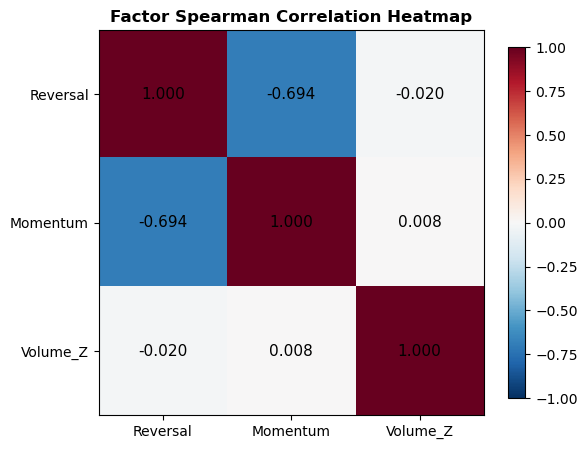

In [53]:
# ===================== Statistical Independence Tests =====================
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

print("=" * 60)
print("STATISTICAL INDEPENDENCE TESTS")
print("=" * 60)

# ---------- 1. Return Series Independence ----------
print("\n1. RETURN SERIES AUTOCORRELATION TESTS")
print("-" * 60)

# Ljung-Box on 5-min returns
lb_5min = acorr_ljungbox(portfolio_returns, lags=10, return_df=True)
lb_5min_pval = lb_5min['lb_pvalue'].iloc[-1]
print(f"5-Min Returns Ljung-Box (lag 10) p-value : {lb_5min_pval:.6f}")
if lb_5min_pval < 0.05:
    print("    => Reject H0: 5-min returns show significant autocorrelation.")
else:
    print("    => Fail to reject H0: 5-min returns appear independent.")

# Ljung-Box on daily returns (computed from portfolio_returns)
daily_rets_ind = portfolio_returns.resample('D').apply(lambda x: (1+x).prod() - 1).dropna()
if len(daily_rets_ind) > 10:
    lb_daily = acorr_ljungbox(daily_rets_ind, lags=min(5, len(daily_rets_ind)//2), return_df=True)
    lb_daily_pval = lb_daily['lb_pvalue'].iloc[-1]
    print(f"Daily Returns Ljung-Box (lag {min(5, len(daily_rets_ind)//2)}) p-value : {lb_daily_pval:.6f}")
    if lb_daily_pval < 0.05:
        print("    => Reject H0: daily returns show significant autocorrelation.")
    else:
        print("    => Fail to reject H0: daily returns appear independent.")
else:
    print("Daily returns sample too small for Ljung-Box test.")

# Durbin-Watson
dw_5min = durbin_watson(portfolio_returns)
dw_daily = durbin_watson(daily_rets_ind) if len(daily_rets_ind) > 1 else np.nan
print(f"\nDurbin-Watson (5-min) : {dw_5min:.4f}  (≈2 suggests no autocorr)")
print(f"Durbin-Watson (daily) : {dw_daily:.4f}")

# ---------- 2. Factor Independence ----------
print("\n2. FACTOR CROSS-CORRELATION (Spearman)")
print("-" * 60)

# Re-run strategy to collect daily factor snapshots
strategy_fac = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)
factor_reversal = []
factor_momentum = []
factor_volume = []

for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_fac.step(prices_arr, volumes_arr)
    
    ts = price_data.index[i]
    if ts.hour == 15 and ts.minute == 55:
        if strategy_fac.step_count >= strategy_fac.lookback_medium + 1:
            price_arr = np.array(strategy_fac.price_history)
            vol_arr = np.array(strategy_fac.volume_history)
            current_prices = price_arr[-1]
            
            past_short = price_arr[-1 - strategy_fac.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short
            
            past_medium = price_arr[-1 - strategy_fac.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium
            
            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            
            mask = np.isfinite(reversal_signal) & np.isfinite(momentum_signal) & np.isfinite(volume_signal)
            if mask.sum() > 0:
                factor_reversal.extend(reversal_signal[mask].tolist())
                factor_momentum.extend(momentum_signal[mask].tolist())
                factor_volume.extend(volume_signal[mask].tolist())

factor_df = pd.DataFrame({
    'Reversal': factor_reversal,
    'Momentum': factor_momentum,
    'Volume_Z': factor_volume
})

corr_spear = factor_df.corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(corr_spear.round(4))
print("\n" + "=" * 60)

# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_spear.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_spear.columns)))
ax.set_yticks(range(len(corr_spear.columns)))
ax.set_xticklabels(corr_spear.columns)
ax.set_yticklabels(corr_spear.columns)
for i in range(len(corr_spear.columns)):
    for j in range(len(corr_spear.columns)):
        ax.text(j, i, f"{corr_spear.values[i, j]:.3f}",
                ha='center', va='center', color='black', fontsize=11)
ax.set_title('Factor Spearman Correlation Heatmap', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

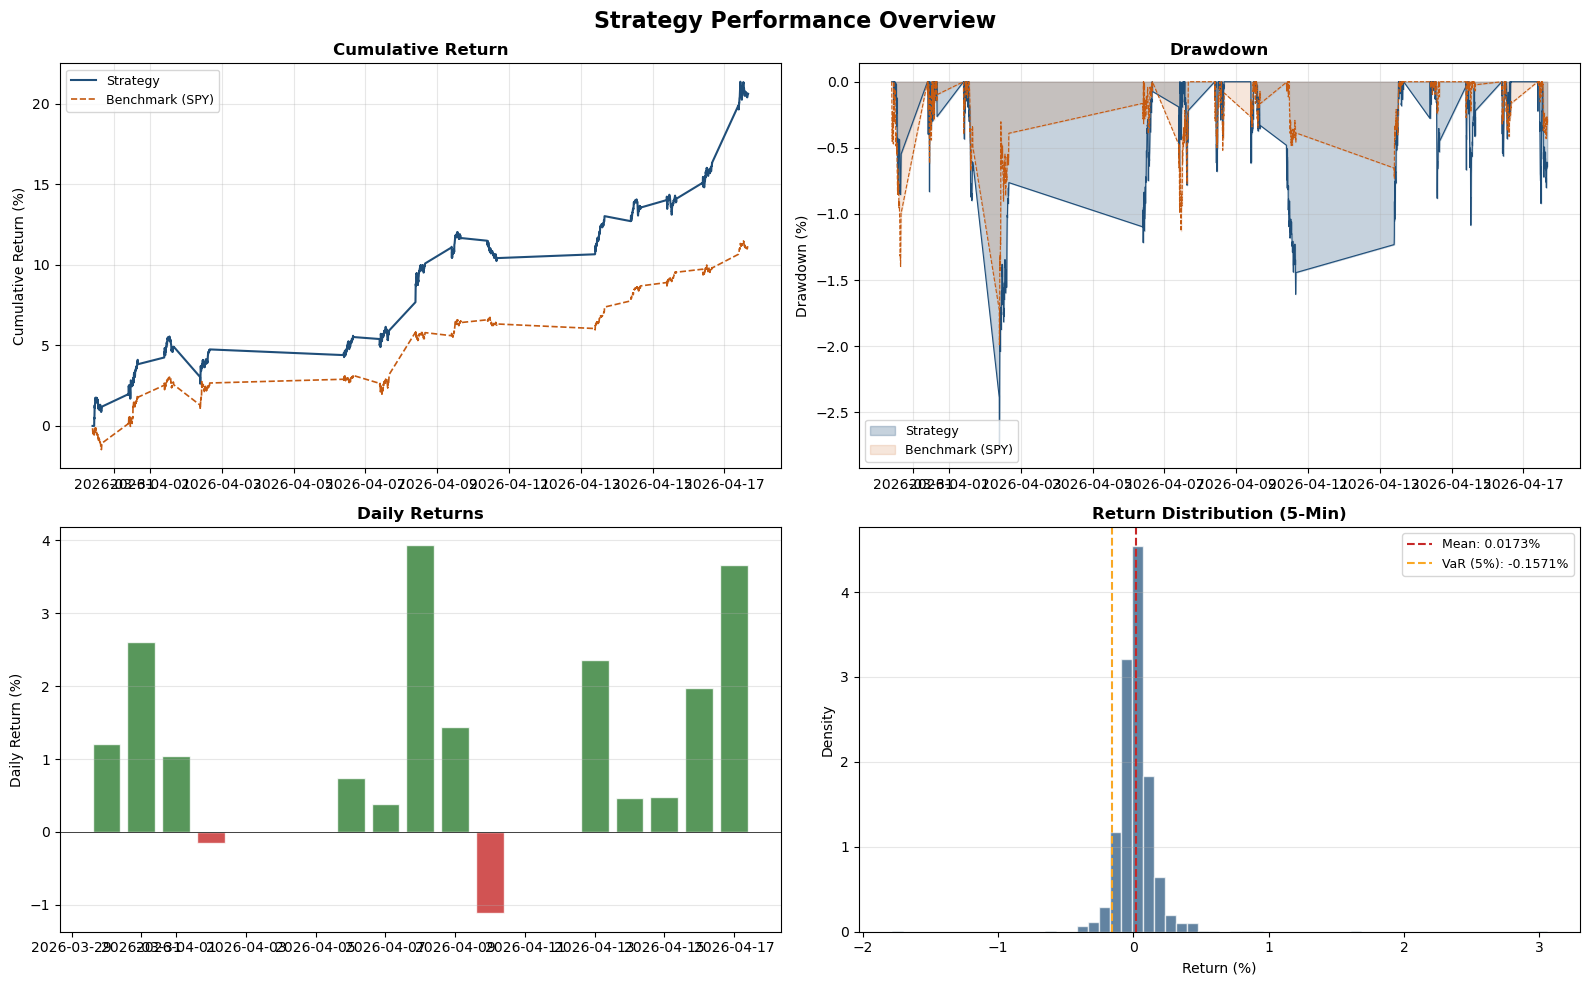


DETAILED PERFORMANCE METRICS
RETURN METRICS
Cumulative Return       : 20.62%
Annualized Return       : 2830.70%
Benchmark (SPY) Cum.    : 11.14%
Benchmark (SPY) Ann.    : 570.92%
Excess Return           : 2259.78%
------------------------------------------------------------
RISK METRICS
Annualized Volatility   : 23.71%
Benchmark Volatility    : 17.80%
Maximum Drawdown        : -2.78%
VaR (5%)                : -0.16%
Skewness                : 5.4618
Excess Kurtosis         : 116.6978


In [54]:
# ===================== Performance Overview =====================

strat_cum = cumulative_returns * 100
spy_cum = spy_cumulative * 100
spy_cumulative_val = (1 + spy_returns).cumprod()
spy_running_max = spy_cumulative_val.expanding().max()
spy_drawdown = (spy_cumulative_val - spy_running_max) / spy_running_max

daily_rets = portfolio_returns.resample('D').apply(lambda x: (1+x).prod() - 1).dropna()
daily_dates = daily_rets.index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Strategy Performance Overview', fontsize=16, fontweight='bold')

# ---------- Figure 1: Performance Overview (2x2) ----------

# 1. Cumulative Return
ax = axes[0, 0]
ax.plot(strat_cum.index, strat_cum, color='#1f4e79', linewidth=1.5, label='Strategy')
ax.plot(spy_cum.index, spy_cum, color='#c55a11', linewidth=1.2, linestyle='--', label='Benchmark (SPY)')
ax.set_title('Cumulative Return', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Drawdown
ax = axes[0, 1]
ax.fill_between(drawdown.index, drawdown * 100, 0, color='#1f4e79', alpha=0.25, label='Strategy')
ax.plot(drawdown.index, drawdown * 100, color='#1f4e79', linewidth=0.8)
ax.fill_between(spy_drawdown.index, spy_drawdown * 100, 0, color='#c55a11', alpha=0.15, label='Benchmark (SPY)')
ax.plot(spy_drawdown.index, spy_drawdown * 100, color='#c55a11', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Daily Returns Bar Chart
ax = axes[1, 0]
colors_bar = ['#2e7d32' if r >= 0 else '#c62828' for r in daily_rets.values]
ax.bar(daily_dates, daily_rets.values * 100, color=colors_bar, edgecolor='white', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Daily Returns', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.grid(True, alpha=0.3, axis='y')

# 4. Return Distribution (5-min)
ax = axes[1, 1]
ax.hist(portfolio_returns * 100, bins=60, color='#1f4e79', edgecolor='white', alpha=0.7, density=True)
ax.axvline(portfolio_returns.mean() * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Mean: {portfolio_returns.mean()*100:.4f}%")
ax.axvline(np.percentile(portfolio_returns * 100, 5), color='#f9a825', linestyle='--', linewidth=1.5,
           label=f"VaR (5%): {np.percentile(portfolio_returns*100,5):.4f}%")
ax.set_title('Return Distribution (5-Min)', fontsize=12, fontweight='bold')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Density')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ---------- Metrics Table ----------

print("\n" + "=" * 60)
print("DETAILED PERFORMANCE METRICS")
print("=" * 60)

print("RETURN METRICS")
print(f"{'Cumulative Return':<23} : {cumulative_returns.iloc[-1] * 100:.2f}%")
print(f"{'Annualized Return':<23} : {annualized_return * 100:.2f}%")
print(f"{'Benchmark (SPY) Cum.':<23} : {spy_cum_ret * 100:.2f}%")
print(f"{'Benchmark (SPY) Ann.':<23} : {spy_annual_return * 100:.2f}%")
print(f"{'Excess Return':<23} : {(annualized_return - spy_annual_return) * 100:.2f}%")
print("-" * 60)

print("RISK METRICS")
print(f"{'Annualized Volatility':<23} : {annualized_vol * 100:.2f}%")
print(f"{'Benchmark Volatility':<23} : {spy_annual_vol * 100:.2f}%")
print(f"{'Maximum Drawdown':<23} : {max_drawdown * 100:.2f}%")
print(f"{'VaR (5%)':<23} : {var_5 * 100:.2f}%")
print(f"{'Skewness':<23} : {skewness:.4f}")
print(f"{'Excess Kurtosis':<23} : {kurtosis:.4f}")
print("=" * 60)


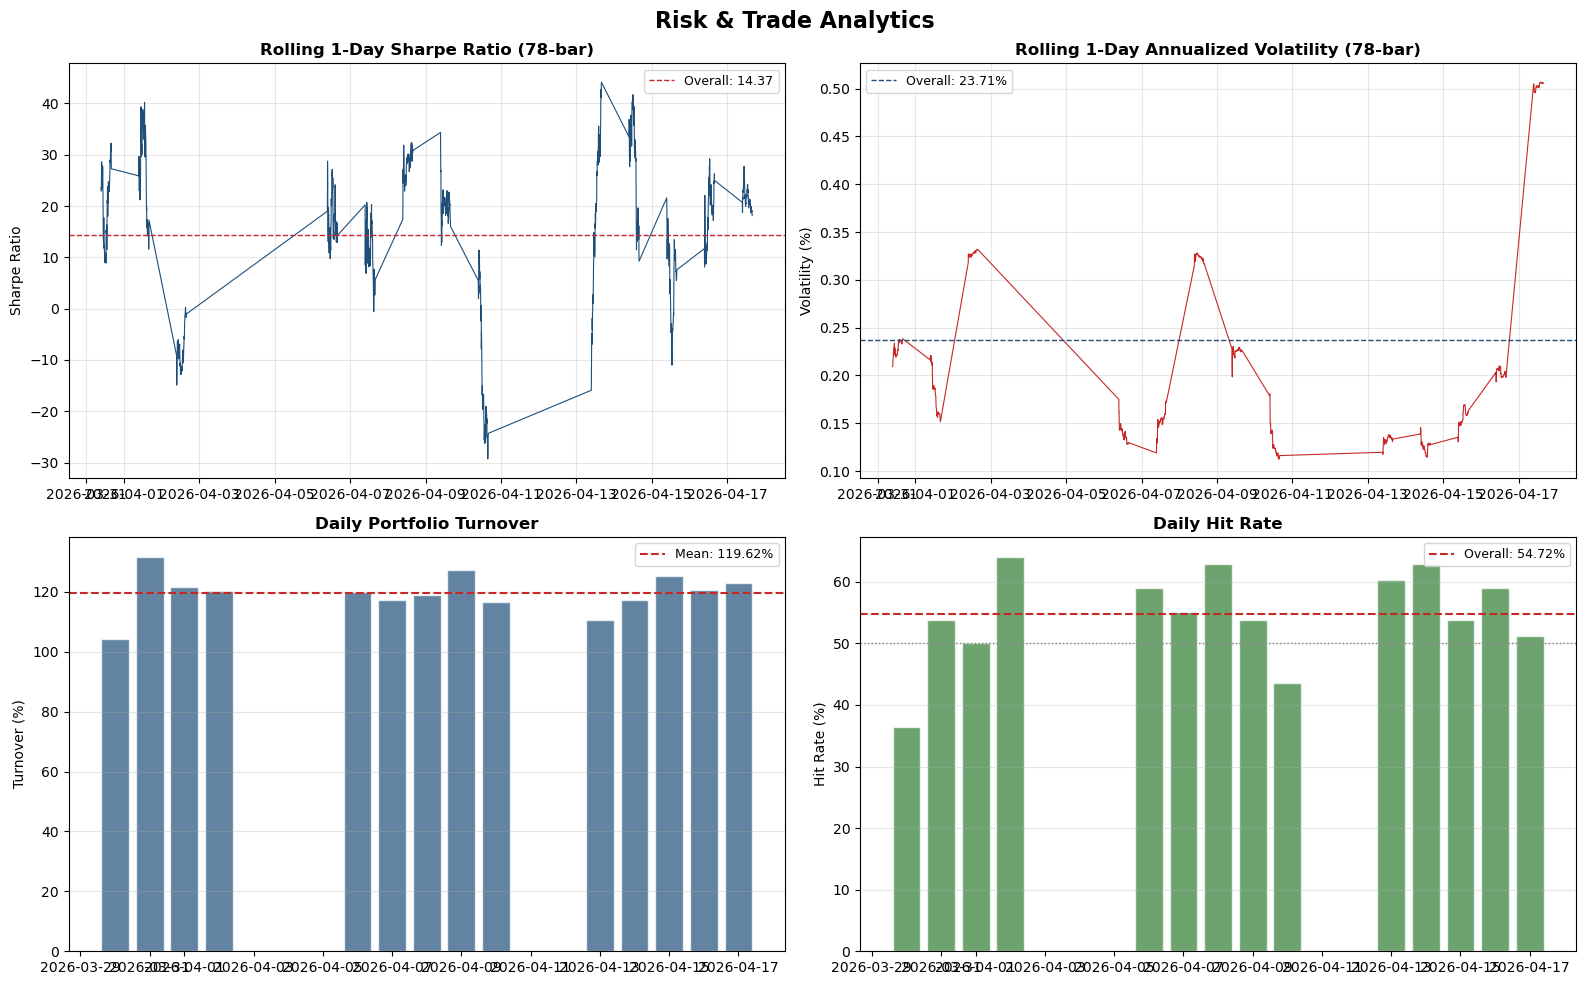


RISK-ADJUSTED & TRADE METRICS
RISK-ADJUSTED METRICS
Sharpe Ratio            : 14.3673
Sortino Ratio           : 22.6628
Calmar Ratio            : 1017.5872
Benchmark Sharpe        : 10.7842
Information Ratio       : 8.1373
------------------------------------------------------------
TRADE STATISTICS
Hit Ratio (Win Rate)    : 54.72%
Profit Factor           : 1.4894
Win/Loss Ratio          : 1.1975
Avg. Gain per Winner    : 0.0964%
Avg. Loss per Loser     : -0.0805%
Est. Annual Turnover    : 23515.13x


In [55]:
# ===================== Risk & Trade Analytics =====================

window = 78
rolling_mean = portfolio_returns.rolling(window=window).mean()
rolling_std = portfolio_returns.rolling(window=window).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252 * 78)
rolling_vol = portfolio_returns.rolling(window=window).std() * np.sqrt(252 * 78)

turnover_series = pd.Series(np.sum(np.abs(np.diff(weights, axis=0)), axis=1), index=portfolio_returns.index)
daily_turnover = turnover_series.resample('D').mean().dropna()
daily_win = (portfolio_returns > 0).astype(int).resample('D').mean().dropna()

tracking_returns = portfolio_returns - spy_returns
tracking_std = tracking_returns.std() * np.sqrt(252 * 78)
info_ratio = (portfolio_returns.mean() * 252 * 78 - spy_returns.mean() * 252 * 78) / tracking_std if tracking_std > 0 else 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Risk & Trade Analytics', fontsize=16, fontweight='bold')

# 1. Rolling Sharpe
ax = axes[0, 0]
ax.plot(rolling_sharpe.index, rolling_sharpe, color='#1f4e79', linewidth=0.8)
ax.axhline(sharpe_ratio, color='#c62828', linestyle='--', linewidth=1, label=f'Overall: {sharpe_ratio:.2f}')
ax.set_title('Rolling 1-Day Sharpe Ratio (78-bar)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Rolling Volatility
ax = axes[0, 1]
ax.plot(rolling_vol.index, rolling_vol, color='#c62828', linewidth=0.8)
ax.axhline(annualized_vol, color='#1f4e79', linestyle='--', linewidth=1, label=f'Overall: {annualized_vol*100:.2f}%')
ax.set_title('Rolling 1-Day Annualized Volatility (78-bar)', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Daily Turnover
ax = axes[1, 0]
ax.bar(daily_turnover.index, daily_turnover.values * 100, color='#1f4e79', edgecolor='white', alpha=0.7)
ax.axhline(daily_turnover.mean() * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Mean: {daily_turnover.mean()*100:.2f}%")
ax.set_title('Daily Portfolio Turnover', fontsize=12, fontweight='bold')
ax.set_ylabel('Turnover (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 4. Daily Win Rate
ax = axes[1, 1]
ax.bar(daily_win.index, daily_win.values * 100, color='#2e7d32', edgecolor='white', alpha=0.7)
ax.axhline(win_rate * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Overall: {win_rate*100:.2f}%")
ax.axhline(50, color='gray', linestyle=':', linewidth=1)
ax.set_title('Daily Hit Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Hit Rate (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ---------- Metrics Table ----------

print("\n" + "=" * 60)
print("RISK-ADJUSTED & TRADE METRICS")
print("=" * 60)

print("RISK-ADJUSTED METRICS")
print(f"{'Sharpe Ratio':<23} : {sharpe_ratio:.4f}")
print(f"{'Sortino Ratio':<23} : {sortino_ratio:.4f}")
print(f"{'Calmar Ratio':<23} : {calmar_ratio:.4f}")
print(f"{'Benchmark Sharpe':<23} : {spy_sharpe:.4f}")
print(f"{'Information Ratio':<23} : {info_ratio:.4f}")
print("-" * 60)

print("TRADE STATISTICS")
print(f"{'Hit Ratio (Win Rate)':<23} : {win_rate * 100:.2f}%")
print(f"{'Profit Factor':<23} : {profit_factor:.4f}")
print(f"{'Win/Loss Ratio':<23} : {win_loss_ratio:.4f}")
print(f"{'Avg. Gain per Winner':<23} : {avg_win * 100:.4f}%")
print(f"{'Avg. Loss per Loser':<23} : {avg_loss * 100:.4f}%")
print(f"{'Est. Annual Turnover':<23} : {annual_turnover:.2f}x")
print("=" * 60)


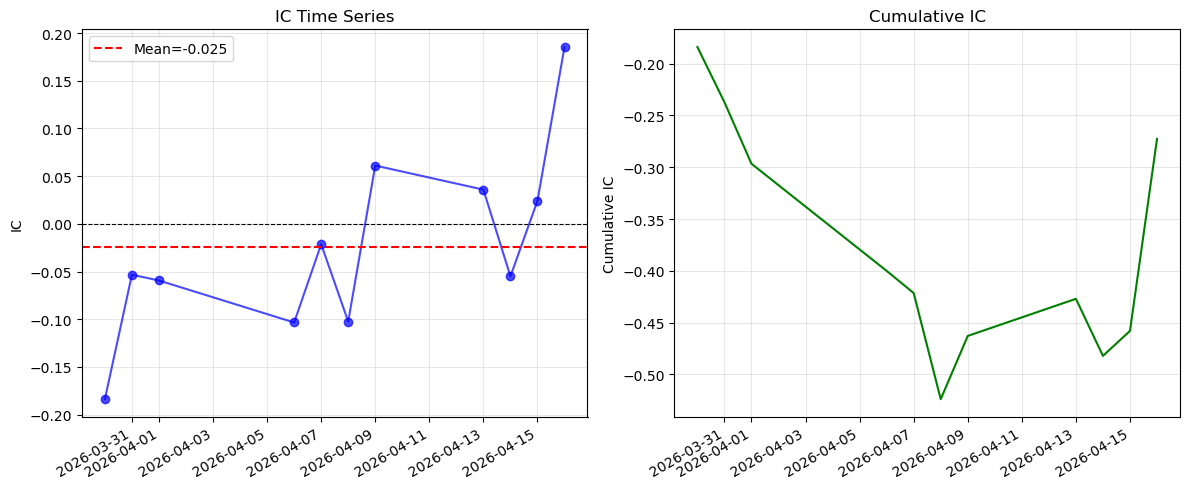

IC Mean:      -0.0248
IC Std:       0.0990
IC IR:        -0.2502


In [ ]:
# ===================== IC Analysis =====================

strategy_ic = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)

factor_dates = []
factor_values = []

for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_ic.step(prices_arr, volumes_arr)

    ts = price_data.index[i]
    if ts.hour == 15 and ts.minute == 55:
        if strategy_ic.step_count >= strategy_ic.lookback_medium + 1:
            price_arr = np.array(strategy_ic.price_history)
            vol_arr = np.array(strategy_ic.volume_history)
            current_prices = price_arr[-1]

            past_short = price_arr[-1 - strategy_ic.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short

            past_medium = price_arr[-1 - strategy_ic.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium

            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            volume_signal = np.clip(volume_signal, -3, 3)

            spy_idx = strategy_ic.spy_idx
            spy_5bar = (price_arr[-1, spy_idx] - price_arr[-6, spy_idx]) / price_arr[-6, spy_idx] if strategy_ic.step_count >= 6 else 0
            spy_medium = ret_medium[spy_idx]

            if spy_5bar > 0.001 or spy_medium > 0.003:
                w_rev, w_mom, w_vol = 0.50, 0.45, 0.05
            elif spy_5bar < -0.001 or spy_medium < -0.003:
                w_rev, w_mom, w_vol = 0.80, 0.15, 0.05
            else:
                w_rev, w_mom, w_vol = 0.90, 0.05, 0.05

            rank_rev = AdaptiveMultiFactorStrategy._rank(reversal_signal)
            rank_mom = AdaptiveMultiFactorStrategy._rank(momentum_signal)
            rank_vol = AdaptiveMultiFactorStrategy._rank(volume_signal)
            composite = w_rev * rank_rev + w_mom * rank_mom + w_vol * rank_vol

            factor_dates.append(ts.date())
            factor_values.append(composite)

factor_matrix = pd.DataFrame(factor_values, index=pd.to_datetime(factor_dates), columns=price_data.columns)

# Next-day daily close-to-close returns
daily_close = price_data[(price_data.index.hour == 15) & (price_data.index.minute == 55)].resample('D').last()
ret_daily = daily_close.pct_change(fill_method=None).shift(-1)
ret_daily.index = ret_daily.index.tz_localize(None)

# Align dates
common_dates = factor_matrix.index.intersection(ret_daily.index)
factor_matrix = factor_matrix.loc[common_dates]
ret_daily = ret_daily.loc[common_dates]

ic_list = []
for date in factor_matrix.index:
    f = factor_matrix.loc[date]
    r = ret_daily.loc[date]
    valid = ~(f.isna() | r.isna())
    f_clean = f[valid]
    r_clean = r[valid]
    if len(f_clean) < 2:
        ic_list.append(np.nan)
        continue
    ic, _ = stats.spearmanr(f_clean, r_clean)
    ic_list.append(ic)

ic_series = pd.Series(ic_list, index=factor_matrix.index)
ic_series = ic_series.dropna()
ic_cumsum = ic_series.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1 = axes[0]
ic_series.plot(ax=ax1, color='blue', alpha=0.7, marker='o')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.axhline(y=ic_series.mean(), color='red', linestyle='--', label=f'Mean={ic_series.mean():.3f}')
ax1.set_title('IC Time Series')
ax1.set_ylabel('IC')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ic_cumsum.plot(ax=ax2, color='green')
ax2.set_title('Cumulative IC')
ax2.set_ylabel('Cumulative IC')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"IC Mean:      {ic_series.mean():.4f}")
print(f"IC Std:       {ic_series.std():.4f}")
print(f"IC IR:        {ic_series.mean()/ic_series.std():.4f}")